In [1]:
import pandas as pd
from db_connection import conn, cursor

Database connected successfully


In [2]:
query = """
SELECT
    w.location_id,
    l.location,
    w.[date],
    w.rainfall,
    w.temperature,
    w.humidity,
    w.pressure,
    w.wind_speed,
    r.river_discharge,
    CASE 
        WHEN lb.date IS NOT NULL THEN 1
        ELSE 0
    END AS flood

FROM weather_data w
JOIN river_data r ON w.location_id = r.location_id
AND CAST(w.[date] AS DATE) = CAST(r.[date] AS DATE)

JOIN location_data l ON w.location_id = l.location_id

LEFT JOIN label_data lb 
ON w.date = lb.date
AND w.location_id = lb.location_id
"""

In [3]:
df = pd.read_sql(query,conn)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_25144\785092515.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


# EDA

In [4]:
df.head()

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood
0,1,Hue,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0
1,1,Hue,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0
2,1,Hue,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0
3,1,Hue,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0
4,1,Hue,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18306 entries, 0 to 18305
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   location_id      18306 non-null  int64  
 1   location         18306 non-null  object 
 2   date             18306 non-null  object 
 3   rainfall         18306 non-null  float64
 4   temperature      18306 non-null  float64
 5   humidity         18306 non-null  float64
 6   pressure         18306 non-null  float64
 7   wind_speed       18306 non-null  float64
 8   river_discharge  18306 non-null  float64
 9   flood            18306 non-null  int64  
dtypes: float64(6), int64(2), object(2)
memory usage: 1.4+ MB


In [6]:
df['date'] = pd.to_datetime(df['date'])

In [7]:
df = df.drop(columns = ['location'])


In [8]:
df.isnull().sum()

location_id        0
date               0
rainfall           0
temperature        0
humidity           0
pressure           0
wind_speed         0
river_discharge    0
flood              0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.duplicated(subset = ['location_id','date']).sum()

np.int64(0)

In [11]:
df.describe()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood
count,18306.000000,18306,18306.000000,18306.000000,18306.000000,18306.000000,18306.000000,18306.000000,18306.000000
mean,1.500000,2014-01-10 00:00:00,7.869933,25.765317,82.986398,1009.338763,14.340560,23.565921,0.175516
min,1.000000,2001-07-01 00:00:00,0.000000,14.100000,45.000000,984.400024,4.200000,0.080000,0.000000
25%,1.000000,2007-10-06 00:00:00,0.200000,23.299999,79.000000,1005.200012,11.300000,0.660000,0.000000
50%,1.500000,2014-01-10 00:00:00,2.150000,26.000000,84.000000,1008.900024,13.600000,6.530000,0.000000
75%,2.000000,2020-04-16 00:00:00,8.400000,28.400000,88.000000,1013.299988,16.600000,14.802500,0.000000
max,2.000000,2026-07-22 00:00:00,398.799988,34.599998,97.000000,1028.400024,64.599998,1569.359985,1.000000
std,0.500014,NaN,16.864720,3.290227,7.112917,5.201800,4.612380,68.753596,0.380418


### 1. Pearson Correlation Heatmap

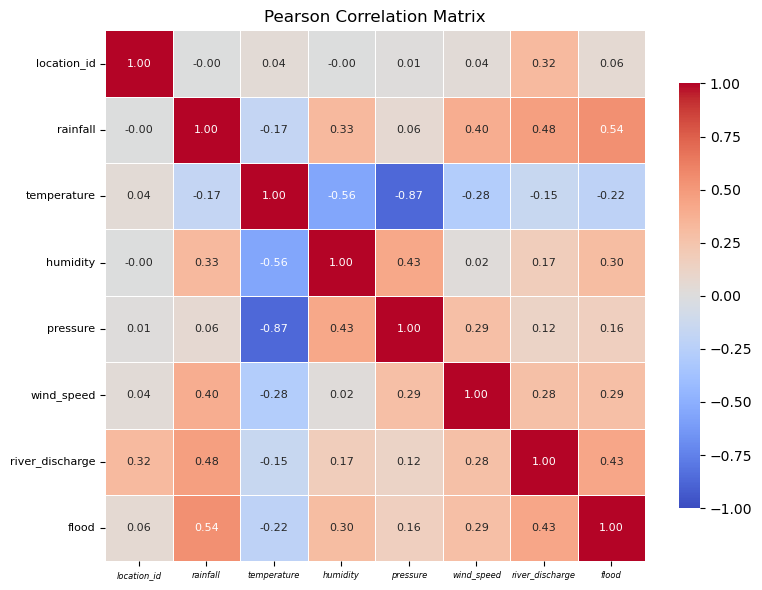

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8},  # Thu nhỏ chữ trong các ô bằng với trục bên dưới
    cbar_kws={"shrink": 0.8}
)

plt.title("Pearson Correlation Matrix", fontsize=12)
plt.xticks(rotation=0, fontsize=6, fontstyle='italic')  # Chữ đứng thẳng, in nghiêng, nhỏ gọn
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

### 2. Flood Label Distribution

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_25144\2692840168.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-Flood", "Flood"])


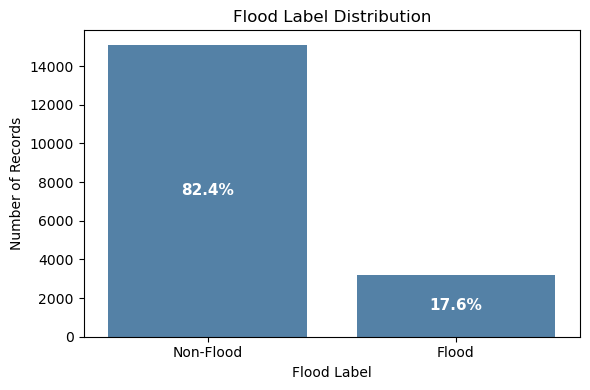

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="flood", color="steelblue")

# Đổi nhãn
ax.set_xticklabels(["Non-Flood", "Flood"])

# Tổng số mẫu
total = len(df)

# Hiển thị % bên trong cột
for p in ax.patches:
    count = p.get_height()
    percent = 100 * count / total

    ax.text(
        p.get_x() + p.get_width()/2,
        count * 0.5,                  # Vị trí giữa cột
        f"{percent:.1f}%",
        ha="center",
        va="center",
        color="white",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Flood Label Distribution")
plt.xlabel("Flood Label")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

### 3. Monthly average total rainfall

THỜI GIAN PHÂN TÍCH DỮ LIỆU: TỪ NĂM 2001 ĐẾN NĂM 2026
=== BẢNG THỐNG KÊ TỔNG LƯỢNG MƯA TRUNG BÌNH THÁNG QUA CÁC NĂM ===
location_name     Hue  Quang Nam
Jan            170.97     204.02
Feb             86.11     103.86
Mar             92.52     106.45
Apr            100.06      69.57
May            194.24     101.86
Jun            150.72     111.25
Jul            169.28     141.58
Aug            211.08     163.96
Sep            374.44     360.82
Oct            526.35     492.77
Nov            451.72     558.92
Dec            360.30     447.40


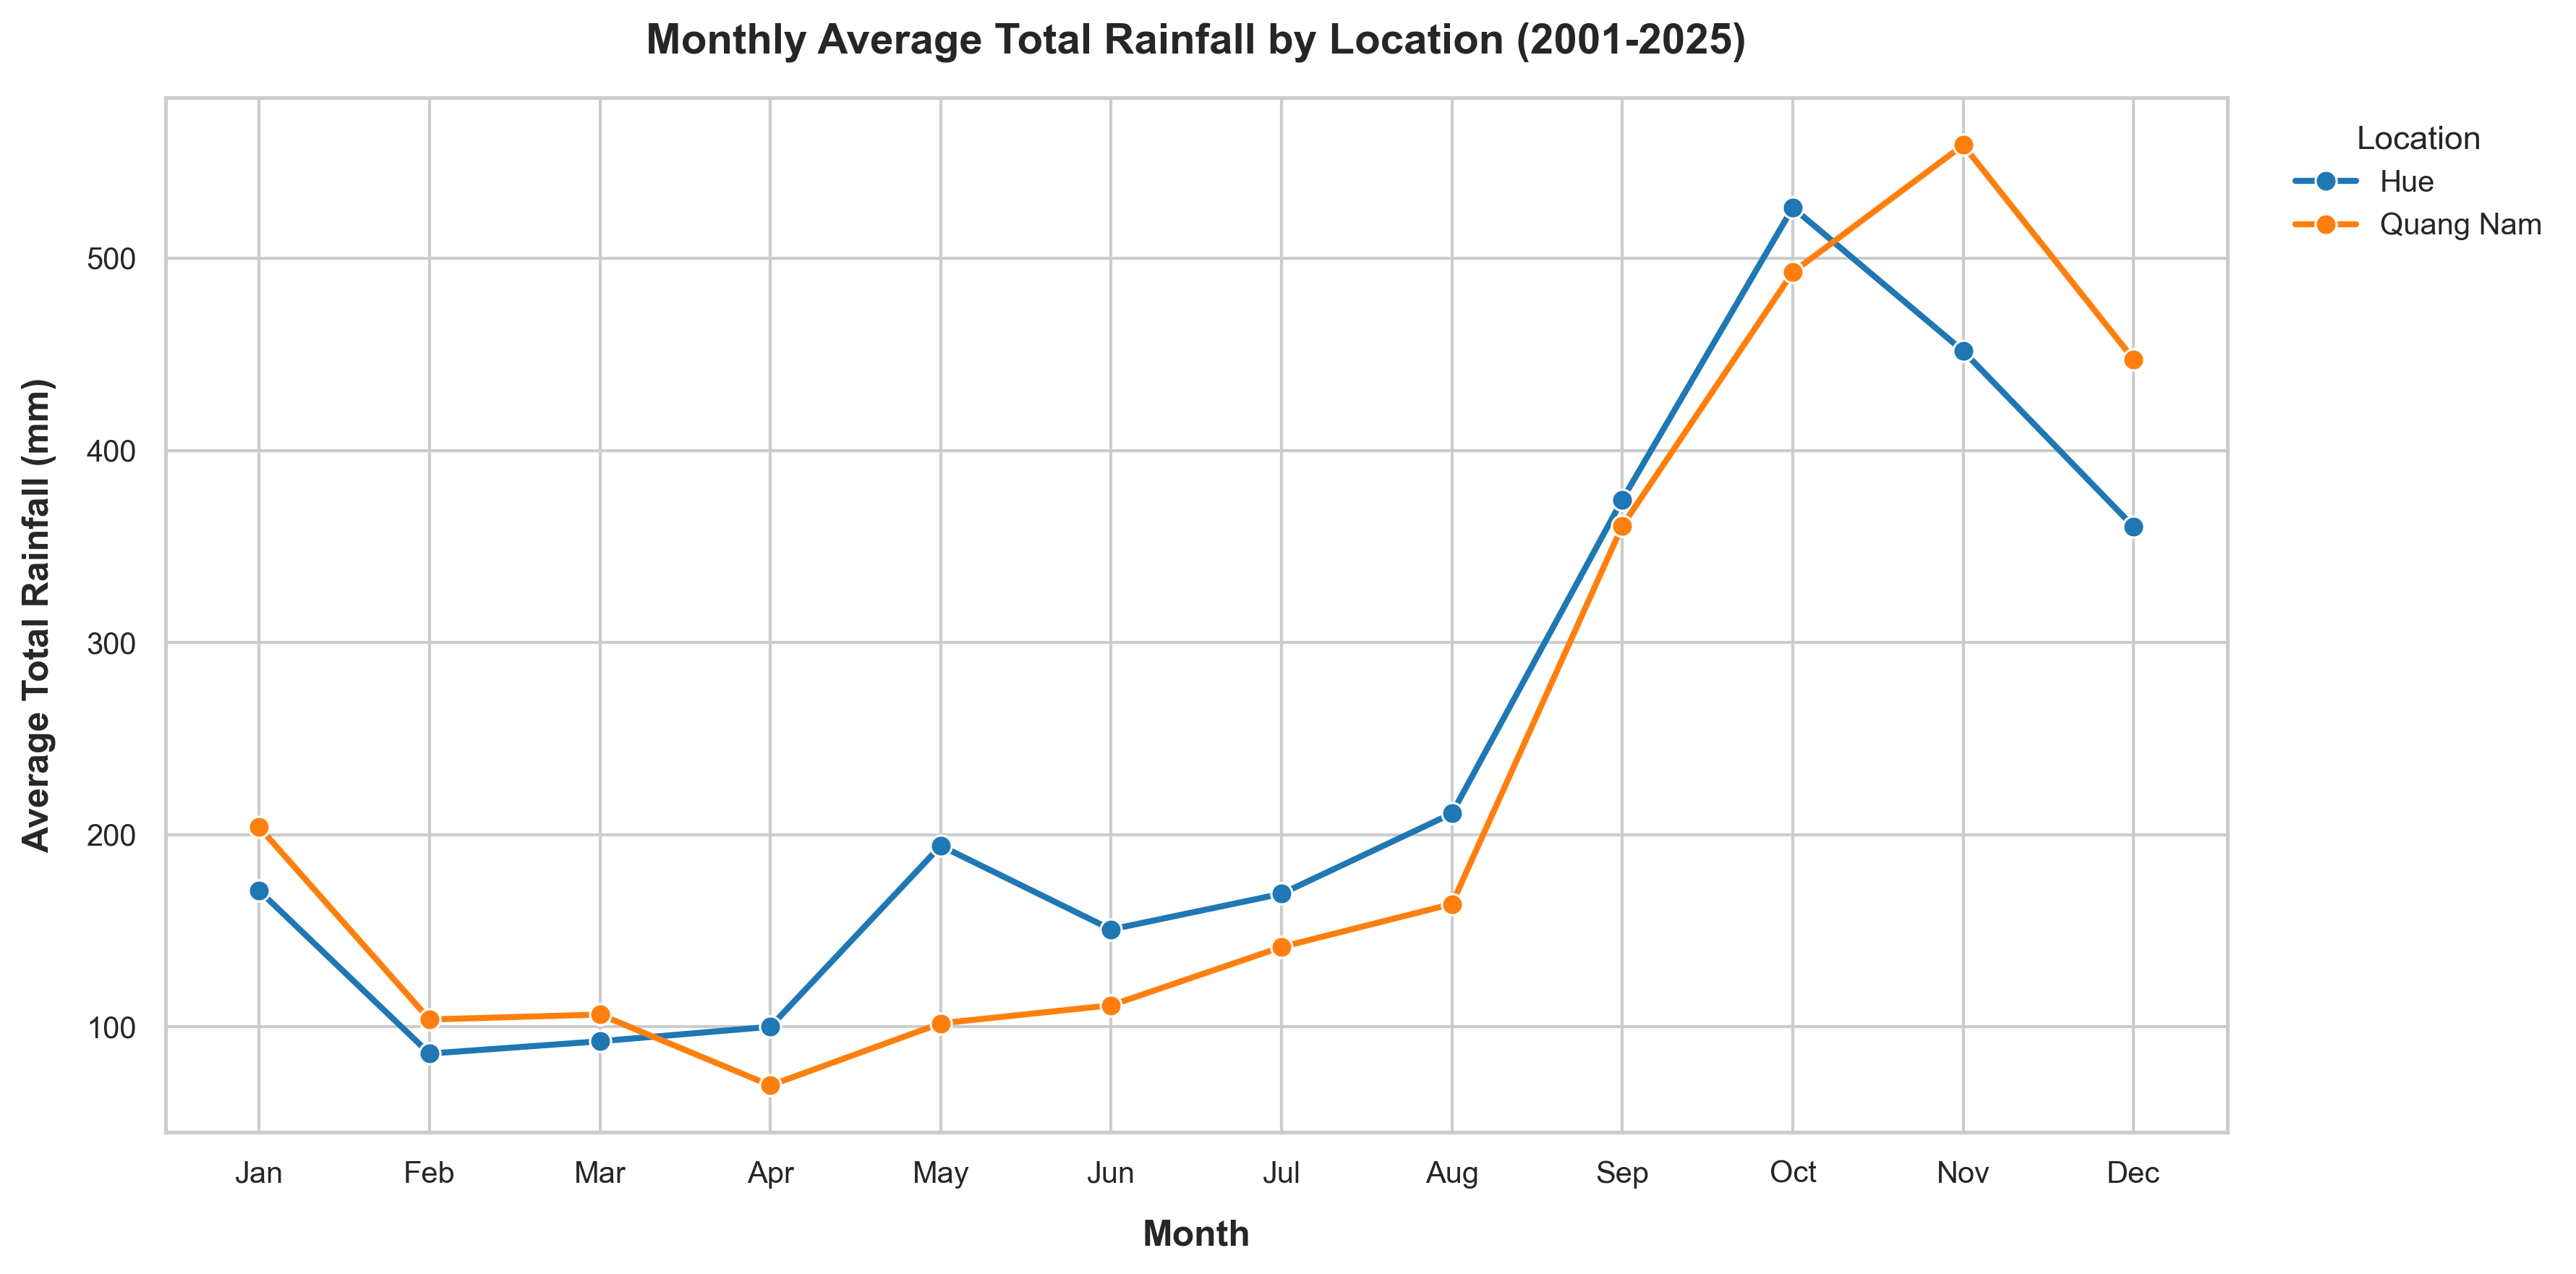

Fig. 3. Monthly average total rainfall pattern for the selected study locations (2001-2025).


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Cài đặt phong cách hiển thị ---
sns.set_theme(style="whitegrid")  # Sử dụng nền lưới sáng, hiện đại
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# 1. Tiền xử lý dữ liệu: Chuyển đổi định dạng ngày và trích xuất Năm, Tháng
df['date'] = pd.to_datetime(df['date'])
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month

# --- TỰ ĐỘNG XÁC ĐỊNH NĂM BẮT ĐẦU VÀ NĂM KẾT THÚC ---
start_year = int(df['Year'].min())
end_year = int(df['Year'].max())

# Ánh xạ tên khu vực (1: Huế, 2: Quảng Nam)
location_names = {
    1: 'Hue',
    2: 'Quang Nam'
}
df['location_name'] = df['location_id'].map(location_names)

# --- CÁCH 2: Tính tổng lượng mưa từng tháng trong mỗi năm, sau đó tính trung bình các năm ---
# Bước 2.1: Tính tổng lượng mưa của mỗi tháng trong từng năm cụ thể
df_monthly_total = df.groupby(['Year', 'Month', 'location_name'], as_index=False)['rainfall'].sum()

# Bước 2.2: Tính trung bình cộng của tổng lượng mưa các tháng đó qua các năm
df_grouped = df_monthly_total.groupby(['Month', 'location_name'], as_index=False)['rainfall'].mean()

# --- In khoảng thời gian và bảng thống kê lượng mưa trung bình các năm ra màn hình ---
print("=" * 65)
print(f"THỜI GIAN PHÂN TÍCH DỮ LIỆU: TỪ NĂM {start_year} ĐẾN NĂM {end_year}")
print("=" * 65)
print("=== BẢNG THỐNG KÊ TỔNG LƯỢNG MƯA TRUNG BÌNH THÁNG QUA CÁC NĂM ===")

df_pivot = df_grouped.pivot(index='Month', columns='location_name', values='rainfall')
df_pivot.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
print(df_pivot.round(2))
print("=" * 65)

# 3. Khởi tạo biểu đồ với kích thước tối ưu
plt.figure(figsize=(12, 6), dpi=300)

# 4. Vẽ biểu đồ đường với bảng màu chuyên nghiệp (palette)
palette = sns.color_palette("tab10", n_colors=df_grouped['location_name'].nunique())

ax = sns.lineplot(
    data=df_grouped,
    x='Month',
    y='rainfall',
    hue='location_name',
    marker='o',
    markersize=7,
    linewidth=2,
    palette=palette
)

# 5. Tùy chỉnh tiêu đề và nhãn trục bằng tiếng Anh (Có kèm theo khoảng năm bắt đầu - kết thúc)
chart_title = f"Monthly Average Total Rainfall by Location ({2001}-{2025})"
plt.title(chart_title, fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Month", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Average Total Rainfall (mm)", fontsize=12, fontweight='bold', labelpad=10)

# 6. Tùy chỉnh trục hoành hiển thị đủ 12 tháng bằng tiếng Anh
plt.xticks(
    ticks=range(1, 13), 
    labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)

# 7. Tùy chỉnh Chú thích (Legend)
plt.legend(
    title="Location", 
    title_fontsize='11',
    fontsize=10,
    loc='upper left', 
    bbox_to_anchor=(1.02, 1),  
    frameon=True,
    facecolor='white',
    edgecolor='none'
)

# 8. Tinh chỉnh bố cục để không bị mất chữ khi xuất ảnh
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In chú thích hình vẽ chuẩn báo cáo khoa học (tiếng Anh, có kèm năm)
print(f"Fig. 3. Monthly average total rainfall pattern for the selected study locations ({2001}-{2025}).")

# CREATE FEATURES|

### Mưa tích lũy 3 ngày

In [15]:
df["rainfall_3d"] = (
    df.groupby("location_id")["rainfall"]
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=3
        ).sum()
    )
)

### Mưa tích lũy 7 ngày 

In [16]:
df["rainfall_7d"] = (
    df.groupby("location_id")["rainfall"]
    .transform(
        lambda x: x.rolling(
            window=7,
            min_periods=7
        ).sum()
    )
)


### Mức thay đổi lưu lượng sông:
* Giá trị dương: nước sông đang tăng
* Giá trị âm: nước sông đang giảm
* Giá trị lớn: nước đang tăng nhanh

In [17]:
df["discharge_change_1d"] = (
    df.groupby("location_id")["river_discharge"]
    .diff(1)
)

df.head()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,Year,Month,location_name,rainfall_3d,rainfall_7d,discharge_change_1d
0,1,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0,2001,7,Hue,NaN,NaN,NaN
1,1,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0,2001,7,Hue,NaN,NaN,-0.09
2,1,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0,2001,7,Hue,2.0,NaN,-0.02
3,1,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0,2001,7,Hue,15.8,NaN,0.02
4,1,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0,2001,7,Hue,15.6,NaN,-0.03


In [18]:
# xóa các dòng null ở đầu 
df = df.dropna().reset_index(drop=True)

### Tạo 3 target ngày cần đoán

In [19]:
df["target_d1"] = (
    df.groupby("location_id")["flood"]
    .shift(-1)
)

df["target_d2"] = (
    df.groupby("location_id")["flood"]
    .shift(-2)
)

df["target_d3"] = (
    df.groupby("location_id")["flood"]
    .shift(-3)
)

df.tail()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,Year,Month,location_name,rainfall_3d,rainfall_7d,discharge_change_1d,target_d1,target_d2,target_d3
18289,2,2026-07-18,2.8,33.599998,50.0,1004.000000,15.1,6.85,0,2026,7,Quang Nam,4.7,21.3,-0.96,0.0,0.0,0.0
18290,2,2026-07-19,0.4,33.900002,47.0,1004.200012,10.7,6.64,0,2026,7,Quang Nam,4.5,14.3,-0.21,0.0,0.0,0.0
18291,2,2026-07-20,2.1,32.799999,52.0,1004.700012,19.9,6.53,0,2026,7,Quang Nam,5.3,7.9,-0.11,0.0,0.0,NaN
18292,2,2026-07-21,0.1,33.400002,49.0,1005.400024,13.0,6.41,0,2026,7,Quang Nam,2.6,7.6,-0.12,0.0,NaN,NaN
18293,2,2026-07-22,2.3,32.299999,55.0,1005.599976,20.6,6.18,0,2026,7,Quang Nam,4.5,9.6,-0.23,NaN,NaN,NaN


In [20]:
df = df.dropna(
    subset=["target_d1", "target_d2", "target_d3"]
).reset_index(drop=True)

df.tail()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,Year,Month,location_name,rainfall_3d,rainfall_7d,discharge_change_1d,target_d1,target_d2,target_d3
18283,2,2026-07-15,0.3,32.200001,59.0,1004.700012,20.6,7.57,0,2026,7,Quang Nam,9.2,32.200000,0.160000,0.0,0.0,0.0
18284,2,2026-07-16,0.6,33.500000,50.0,1005.200012,19.9,8.27,0,2026,7,Quang Nam,1.3,29.500001,0.700000,0.0,0.0,0.0
18285,2,2026-07-17,1.3,33.500000,50.0,1004.700012,16.6,7.81,0,2026,7,Quang Nam,2.2,19.700000,-0.460001,0.0,0.0,0.0
18286,2,2026-07-18,2.8,33.599998,50.0,1004.000000,15.1,6.85,0,2026,7,Quang Nam,4.7,21.300000,-0.960000,0.0,0.0,0.0
18287,2,2026-07-19,0.4,33.900002,47.0,1004.200012,10.7,6.64,0,2026,7,Quang Nam,4.5,14.300000,-0.210000,0.0,0.0,0.0


In [21]:
target_cols = [
    'target_d1',
    'target_d2',
    'target_d3'
]

df[target_cols] = df[target_cols].astype('int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18288 entries, 0 to 18287
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   location_id          18288 non-null  int64         
 1   date                 18288 non-null  datetime64[ns]
 2   rainfall             18288 non-null  float64       
 3   temperature          18288 non-null  float64       
 4   humidity             18288 non-null  float64       
 5   pressure             18288 non-null  float64       
 6   wind_speed           18288 non-null  float64       
 7   river_discharge      18288 non-null  float64       
 8   flood                18288 non-null  int64         
 9   Year                 18288 non-null  int32         
 10  Month                18288 non-null  int32         
 11  location_name        18288 non-null  object        
 12  rainfall_3d          18288 non-null  float64       
 13  rainfall_7d          18288 non-

In [22]:
df.head()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,Year,Month,location_name,rainfall_3d,rainfall_7d,discharge_change_1d,target_d1,target_d2,target_d3
0,1,2001-07-07,0.5,30.200001,68.0,998.400024,23.1,0.36,0,2001,7,Hue,0.5,16.3,-0.01,0,0,0
1,1,2001-07-08,38.0,28.400000,82.0,1003.099976,6.2,0.70,0,2001,7,Hue,38.5,54.3,0.34,0,0,0
2,1,2001-07-09,6.7,28.000000,80.0,1006.400024,8.1,1.28,0,2001,7,Hue,45.2,60.8,0.58,0,0,0
3,1,2001-07-10,0.2,28.200001,79.0,1006.200012,9.2,0.92,0,2001,7,Hue,44.9,59.2,-0.36,0,0,0
4,1,2001-07-11,0.8,28.600000,80.0,1004.700012,9.1,0.58,0,2001,7,Hue,7.7,46.2,-0.34,0,0,0


In [23]:
df.to_csv("../data/train/train_data.csv",index = False)
print("done")

done
